In [10]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import arc
import pairinteraction as pi
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=False)
import os
from IPython.display import Latex
import scipy
import pandas as pd
from pandas import DataFrame
import sys
sys.path.append(os.path.abspath("C:\\Users\\Tommy\\OneDrive - Durham University\\level 4 Project\\Code Directory\\L4-code-directory-2"))
from my_functions import *
h = scipy.constants.h
epsilon_0 = scipy.constants.epsilon_0
a_0 = scipy.constants.physical_constants['Bohr radius']
e = scipy.constants.e


In [11]:
from pairinteraction.visualization.colormaps import alphamagma
import os
colours = ('orange', 'green', 'red', 'blue')
orbs = ('s', 'p', 'd', 'f')

atom1 = 'Rb'
atom2 ='Cs'
l1_0, l2_0 = 0, 0
l1_1, l2_1 = 1, 1
j1_0, j2_0 = 1/2, 1/2


if atom1 == 'Rb':
    arc_atom1 = arc.Rubidium()
elif atom1 == 'Cs':
    arc_atom1 = arc.Caesium()
if atom2 == 'Rb':
    arc_atom2 = arc.Rubidium()
elif atom2 == 'Cs':
    arc_atom2 = arc.Caesium()  

energy_unit = 'MHz'
    

In [12]:
n_dif=2
ldif=1
jdif=1
def get_system_pair_list_r(
    ket1: pi.SystemAtom, ket2: pi.SystemAtom, rs: np.ndarray, erange, theta, b, e
) -> list[pi.SystemPair]:


    basis1 = pi.BasisAtom(ket1.species, n=(ket1.n-n_dif, ket1.n+n_dif), l=(0,ket1.l+ldif), j=(1/2,ket1.j+jdif), m=(-ket1.j-jdif, ket1.j+jdif))
    basis2 = pi.BasisAtom(ket2.species, n=(ket2.n-n_dif, ket2.n+n_dif), l=(0,ket2.l+ldif), j=(1/2,ket2.j+jdif), m=(-ket2.j-jdif, ket2.j+jdif))



    system1, system2 = pi.SystemAtom(basis1).set_magnetic_field([0,0,b], unit='G').set_electric_field([0,0,e], unit='V/cm').set_diamagnetism_enabled(True), pi.SystemAtom(basis2).set_magnetic_field([0,0,b], unit='G').set_electric_field([0,0,e], unit='V/cm').set_diamagnetism_enabled(True)


    pi.diagonalize([system1, system2])

    pair_energy = system1.get_corresponding_energy(ket1, unit=energy_unit) + system2.get_corresponding_energy(ket2, unit=energy_unit)
    min_energy, max_energy = pair_energy - erange, pair_energy + erange

    pair_basis = pi.BasisPair(
            [system1, system2], energy=(min_energy, max_energy), energy_unit=energy_unit
        )

    pair_systems = []
    for i, r in enumerate(rs):
                
        # print(f'pair energy = {pair_energy}{energy_unit}')
            
        
        pair_systems.append(
            pi.SystemPair(pair_basis)
            .set_distance(r, unit='um', angle_degree=theta)
            )
        states_num = pair_basis.number_of_states
        # print(f"Number of two-atom basis states: {pair_basis.number_of_states}")


    # Diagonalize the systems in parallel
    pi.diagonalize(
        pair_systems,
        diagonalizer="lapacke_evd",
        energy_range=(min_energy, max_energy),
        energy_range_unit=energy_unit,
    )
    
    energies = [system.get_eigenenergies(unit = energy_unit) - pair_energy for system in pair_systems]

    return pair_systems, states_num, energies

In [13]:
channels = channels_import(atom1, l1_0, j1_0, atom2, l2_0, j2_0, l1_1, l2_1)

    n1_0  l1_0  j1_0  n2_0  l2_0  j2_0  n1_1  l1_1  j1_1  n2_1  l2_1  j2_1  \
0     45     0   0.5    47     0   0.5    45     1   1.5    46     1   1.5   
1     46     0   0.5    48     0   0.5    46     1   1.5    47     1   1.5   
2     48     0   0.5    51     0   0.5    48     1   1.5    50     1   0.5   
3     59     0   0.5    57     0   0.5    58     1   0.5    57     1   0.5   
4     61     0   0.5    65     0   0.5    61     1   0.5    64     1   0.5   
5     68     0   0.5    67     0   0.5    67     1   0.5    67     1   1.5   
6     69     0   0.5    68     0   0.5    68     1   0.5    68     1   1.5   
7     71     0   0.5    69     0   0.5    70     1   1.5    69     1   0.5   
8     72     0   0.5    70     0   0.5    71     1   1.5    70     1   0.5   
9     72     0   0.5    75     0   0.5    72     1   0.5    74     1   1.5   
10    73     0   0.5    76     0   0.5    73     1   0.5    75     1   1.5   
11    77     0   0.5    81     0   0.5    77     1   1.5    80  

In [14]:
channel = 14
c = channels.loc[channel]
# set atom properties
n1_0, l1_0, j1_0 = int(c['n1_0']), int(c['l1_0']), c['j1_0']
n2_0, l2_0, j2_0 = int(c['n2_0']), int(c['l2_0']), c['j2_0'] 
mj1_0s, mj2_0s = np.arange(-j1_0, j1_0+1), np.arange(-j2_0, j2_0+1)
f1_0, f2_0 = 1, 1

n1_1, l1_1, j1_1 = int(c['n1_1']), int(c['l1_1']), c['j1_1']
n2_1, l2_1, j2_1 =  int(c['n2_1']), int(c['l2_1']), c['j2_1']
f1_1, f2_1 = 1, 1

ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=j1_0, j=j1_0)
ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=j2_0, j=j2_0)
ket1_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=j1_1)
ket2_1 = pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1, m=j2_1)
ket1_energy = ket1.get_energy(unit=energy_unit)
ket2_energy = ket2.get_energy(unit=energy_unit)

defect = c['defect']


bfield = 0  # Gauss
erange = abs(defect + defect*1000)



In [15]:
ket1, ket2 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=-j1_0), pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=-j2_0)
rs = np.linspace(2, 40, 500)
rs = np.append(rs, [5000])
e=0
b=0
thetas = [0, 45, 90]
system_pairs_dict: dict[float, list[pi.SystemPair]] = {}
system_pairs_dict_inter = {}
system_pairs_dict_Rb = {}
system_pairs_dict_Cs = {}
energies_inter_dict = {}
energies_intra_Rb_dict = {}
energies_intra_Cs_dict = {}
for theta in thetas:
    while True:
        try:
            pairs = get_system_pair_list_r(ket1, ket2, rs, erange, theta, b, e)
            system_pairs = pairs[0]
            states_num = pairs[1]
            energies = pairs[2]

            pairs_Rb = get_system_pair_list_r(ket1, ket1, rs, erange, theta, b, e)
            system_pairs_Rb = pairs_Rb[0]
            states_num_Rb = pairs_Rb[1]
            energies_Rb = pairs_Rb[2]

            pairs_Cs = get_system_pair_list_r(ket2, ket2, rs, erange, theta, b, e)
            system_pairs_Cs = pairs_Cs[0]
            states_num_Cs = pairs_Cs[1]
            energies_Cs = pairs_Cs[2]
            
            system_pairs_dict_inter.update({f'{theta}{b}': system_pairs})
            energies_inter_dict.update({f'{theta}{b}' : energies})

            system_pairs_dict_Rb.update({f'{theta}{b}': system_pairs_Rb})
            energies_intra_Rb_dict.update({f'{theta}{b}' : energies_Rb})

            system_pairs_dict_Cs.update({f'{theta}{b}': system_pairs_Cs})
            energies_intra_Cs_dict.update({f'{theta}{b}' : energies_Cs})
            break
        except RuntimeError: # Replace Exception with something more specific.
            continue


A bijective map between states and kets could not be found.
A bijective map between states and kets could not be found.
A bijective map between states and kets could not be found.
A bijective map between states and kets could not be found.
A bijective map between states and kets could not be found.
A bijective map between states and kets could not be found.
A bijective map between states and kets could not be found.
A bijective map between states and kets could not be found.
A bijective map between states and kets could not be found.
A bijective map between states and kets could not be found.
A bijective map between states and kets could not be found.
A bijective map between states and kets could not be found.
A bijective map between states and kets could not be found.
A bijective map between states and kets could not be found.
A bijective map between states and kets could not be found.
A bijective map between states and kets could not be found.
A bijective map between states and kets 

In [16]:
import os
datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\'
if not os.path.exists(datapath + 'inter'):
    os.makedirs(datapath + 'inter')
if not os.path.exists(datapath + 'intra Rb'):
    os.makedirs(datapath + 'intra Rb')
if not os.path.exists(datapath + 'intra Cs'):
    os.makedirs(datapath + 'intra Cs')


energies_inter_dict.update({'rs' : rs})

energies_intra_Rb_dict.update({'rs' : rs})

energies_intra_Cs_dict.update({'rs' : rs})
print(states_num, states_num_Rb, states_num_Cs)
    

148 164 164


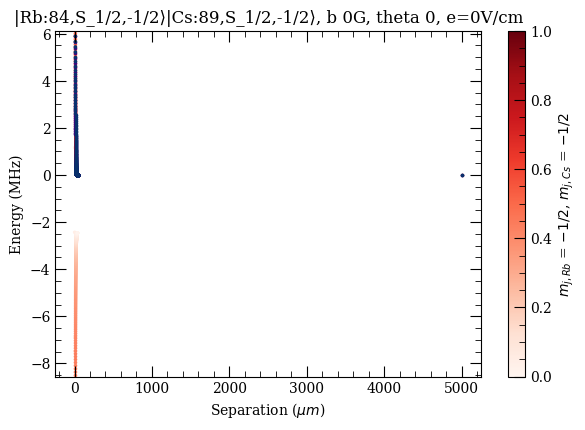

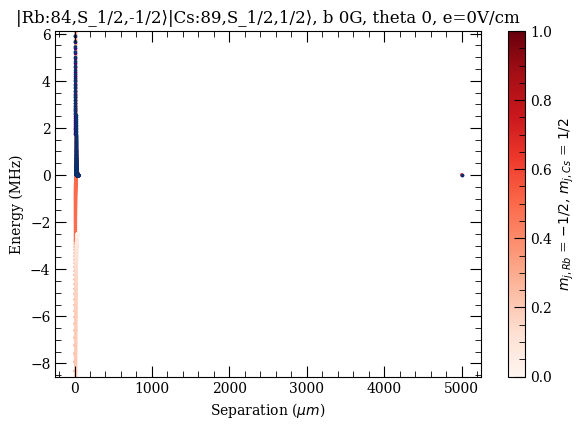

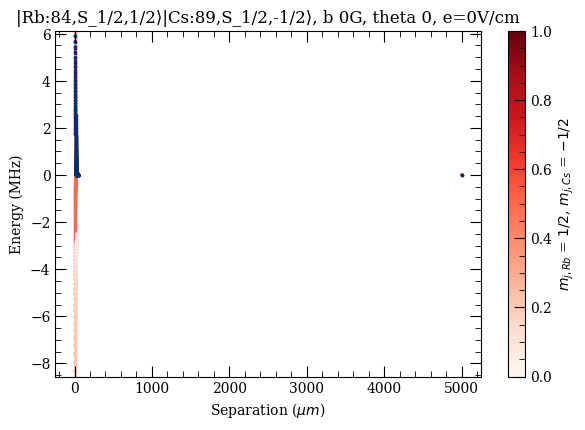

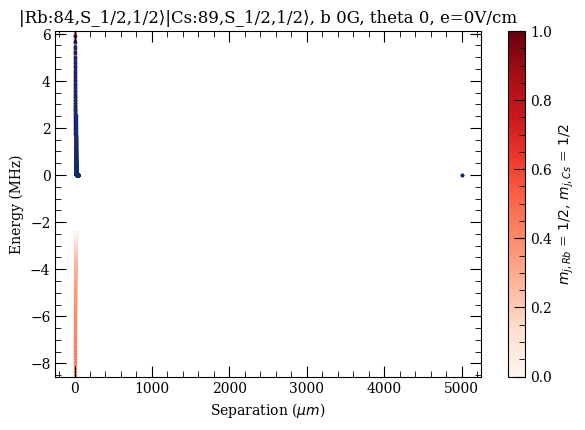

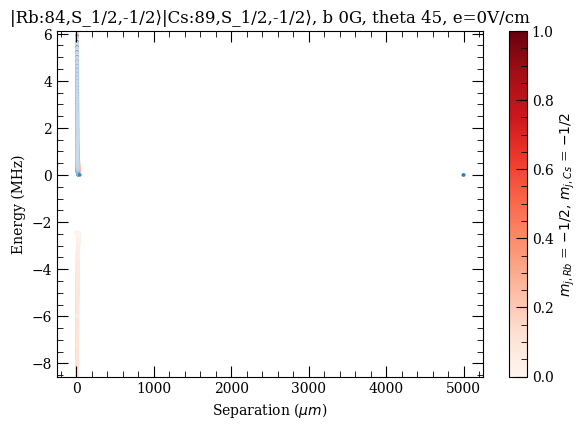

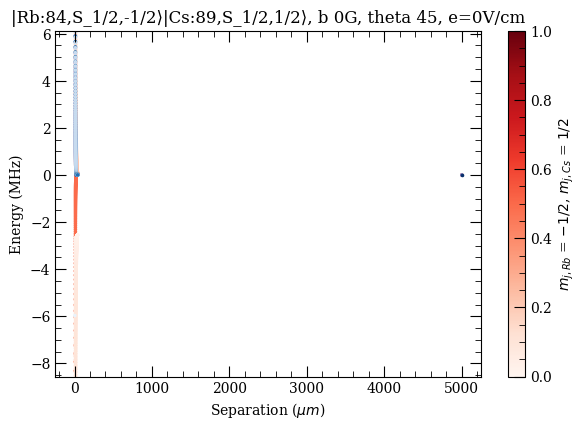

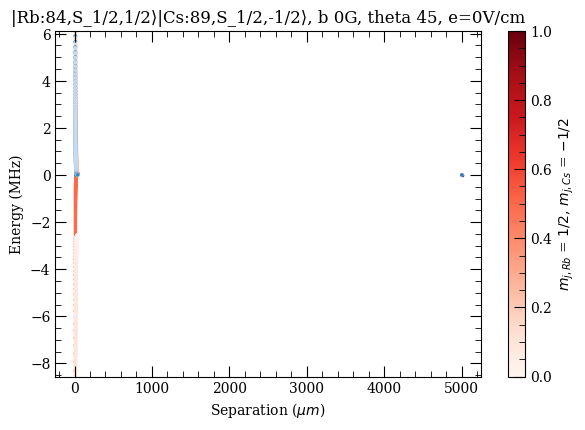

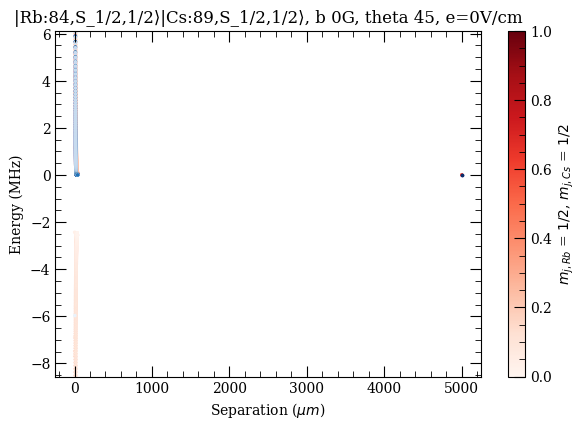

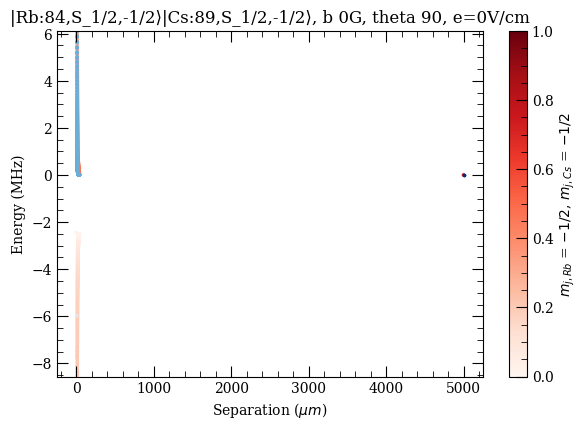

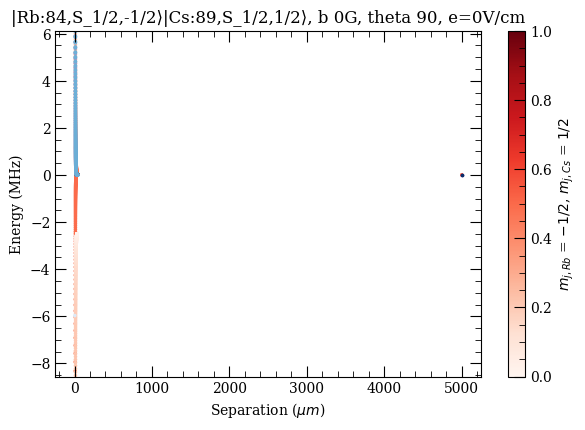

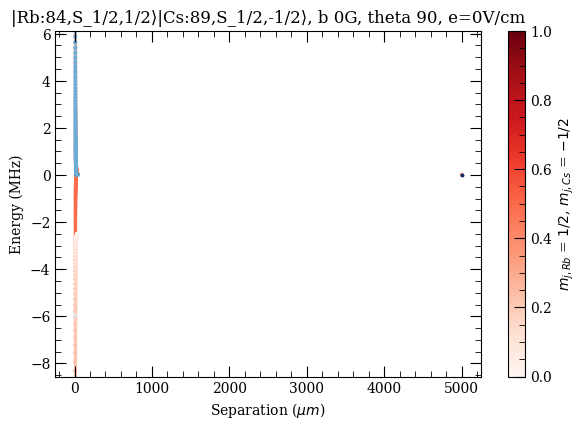

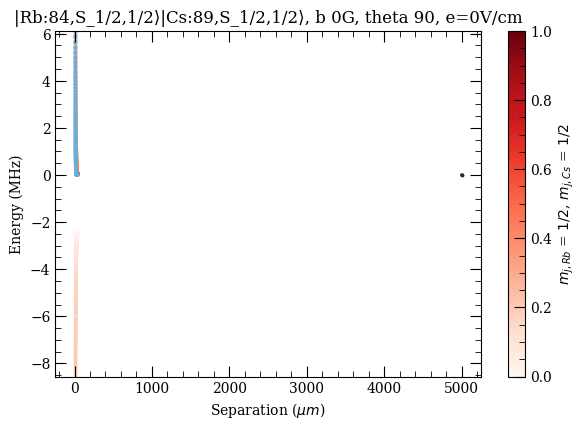

In [17]:
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)

# ax.set_ylim(-0.01, 0.01)

prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']


for theta in thetas:
    for mj1 in mj1_0s:
        for mj2 in mj2_0s:
            import os

            ket1, ket2 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=mj1), pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=mj2)

            system_pairs = system_pairs_dict_inter[f'{theta}{b}']
            system_pairs_Rb = system_pairs_dict_Rb[f'{theta}{b}']
            system_pairs_Cs = system_pairs_dict_Cs[f'{theta}{b}']

            overlaps_inter = [system.get_eigenbasis().get_overlaps([ket1, ket2]) for system in system_pairs]
            overlaps_intra_Rb = [system.get_eigenbasis().get_overlaps([ket1, ket1]) for system in system_pairs_Rb]
            overlaps_intra_Cs = [system.get_eigenbasis().get_overlaps([ket2, ket2]) for system in system_pairs_Cs]

            energies_inter = energies_inter_dict[f'{theta}{b}']
            energies_intra_Rb = energies_intra_Rb_dict[f'{theta}{b}']
            energies_intra_Cs = energies_intra_Cs_dict[f'{theta}{b}']
            rs = energies_inter_dict['rs']
            rs_Rb = energies_intra_Rb_dict['rs']
            rs_Cs = energies_intra_Cs_dict['rs']

            # print(energies_inter)
            
                    
            # 2. Build the RGBA array: (N, 4)

            fig, ax = plt.subplots(ncols=1, figsize=(6, 4))

            plt.tight_layout()
            plt.title(fr'{str(ket1)}{str(ket2)}, b {b}G, theta {theta}, e={0}V/cm')
            energy_lim = abs(defect + defect*2)
            offset=defect/2
            min_energy = -energy_lim+offset
            max_energy = energy_lim+offset
            plt.ylim(min_energy, max_energy)
            # plt.xlim(2, 2.7)
            plt.ylabel(f"Energy ({energy_unit})")
            plt.xlabel(fr"Separation ($\mu m$)")
            # ax.plot(e_fields_sub, energies)

            # for x, es in zip(rs, energies_inter):
            #     plt.plot([x] * len(es), es, c='.7', ls="None", marker=".", ms=1, zorder=-1)
            r, energy, overlap = [], [], []
            min_overlap = 0.01
            for x, es, os in zip(rs, energies_inter, overlaps_inter):
                inds = np.argwhere(os > min_overlap).flatten()
                inds = inds[np.argsort(os[inds])]
                if len(inds) > 0:
                    r.extend([x] * len(es[inds]))
                    energy.extend(es[inds])
                    overlap.extend(os[inds])

                    rgba = np.zeros((len(es[inds]), 4))
                    base_rgb = mcolors.to_rgb(colours[0])
                    rgba[:, :3] = base_rgb
                    rgba[:, 3] = os[inds]

                    scat = plt.scatter(
                        [x] * len(es[inds]),
                        es[inds],
                        c=os[inds],
                        s=10,
                        vmin=0,
                        vmax=1,
                        marker='.',
                        cmap = 'Reds'
                    )
            overlapped_inter = {'r' : np.array(r), 'energy' : np.array(energy), 'overlap' : np.array(overlap)}
            fig.colorbar(scat, ax=ax, label=fr"$m_{{j,Rb}}$ = ${int(ket1.m*2)}/2$, $m_{{j,Cs}}$ = ${int(ket2.m*2)}/2$")

            r, energy, overlap = [], [], []
            for x, es, os in zip(rs_Rb, energies_intra_Rb, overlaps_intra_Rb):
                inds = np.argwhere(os > min_overlap).flatten()
                inds = inds[np.argsort(os[inds])]
                if len(inds) > 0:
                    r.extend([x] * len(es[inds]))
                    energy.extend(es[inds])
                    overlap.extend(os[inds])

                    rgba = np.zeros((len(es[inds]), 4))
                    base_rgb = mcolors.to_rgb(colours[1])
                    rgba[:, :3] = base_rgb
                    rgba[:, 3] = os[inds]
                    scat = plt.scatter(
                        [x] * len(es[inds]),
                        es[inds],
                        c=os[inds],
                        s=10,
                        vmin=0,
                        vmax=1,
                        marker='.',
                        cmap = 'Purples'
                    )
            overlapped_intra_Rb = {'r' : np.array(r), 'energy' : np.array(energy), 'overlap' : np.array(overlap)}
            
            r, energy, overlap = [], [], []
            for x, es, os in zip(rs_Cs, energies_intra_Cs, overlaps_intra_Cs):
                inds = np.argwhere(os > min_overlap).flatten()
                inds = inds[np.argsort(os[inds])]
                if len(inds) > 0:
                    r.extend([x] * len(es[inds]))
                    energy.extend(es[inds])
                    overlap.extend(os[inds])

                    rgba = np.zeros((len(es[inds]), 4))
                    base_rgb = mcolors.to_rgb(colours[2])
                    rgba[:, :3] = base_rgb
                    rgba[:, 3] = os[inds]
                    scat = plt.scatter(
                        [x] * len(es[inds]),
                        es[inds],
                        c=os[inds],
                        s=10,
                        vmin=0,
                        vmax=1,
                        marker='.',
                        cmap = 'Blues'
                    )
            plt.show()
            overlapped_intra_Cs = {'r' : np.array(r), 'energy' : np.array(energy), 'overlap' : np.array(overlap)}
            pd.DataFrame(overlapped_inter).to_csv(datapath + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {b}G.csv')
            pd.DataFrame(overlapped_intra_Rb).to_csv(datapath + f'intra Rb\\mjs ({mj1}, {mj1}), theta {theta}, b {b}G.csv')
            pd.DataFrame(overlapped_intra_Cs).to_csv(datapath + f'intra Cs\\mjs ({mj2}, {mj2}), theta {theta}, b {b}G.csv')
            # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
            # fig.savefig(figpath + f'b {b}G theta{theta} e{e}Vcm mjs{ket1.m},{ket2.m}.png')
            plt.close()


0       2.000000
1       2.076152
2       2.152305
3       2.228457
4       2.304609
         ...    
718    39.390782
719    39.466934
720    39.543086
721    39.619238
722    39.695391
Name: r, Length: 723, dtype: float64


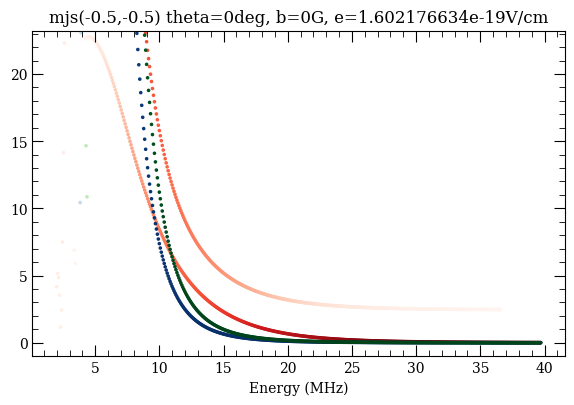

0       2.000000
1       2.076152
2       2.152305
3       2.228457
4       2.304609
         ...    
718    39.390782
719    39.466934
720    39.543086
721    39.619238
722    39.695391
Name: r, Length: 723, dtype: float64


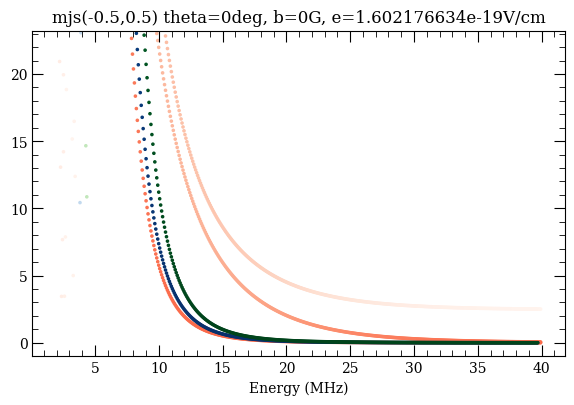

0       2.000000
1       2.076152
2       2.152305
3       2.228457
4       2.304609
         ...    
718    39.390782
719    39.466934
720    39.543086
721    39.619238
722    39.695391
Name: r, Length: 723, dtype: float64


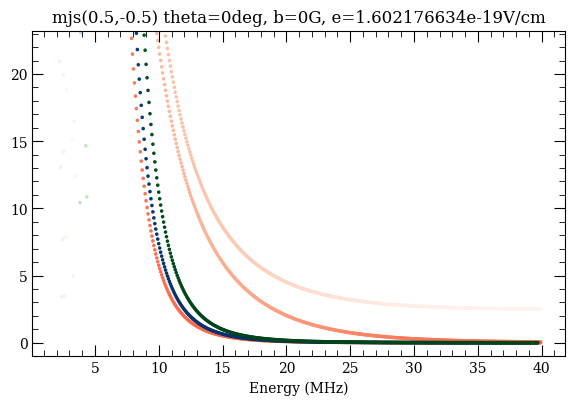

0       2.000000
1       2.076152
2       2.152305
3       2.228457
4       2.304609
         ...    
718    39.390782
719    39.466934
720    39.543086
721    39.619238
722    39.695391
Name: r, Length: 723, dtype: float64


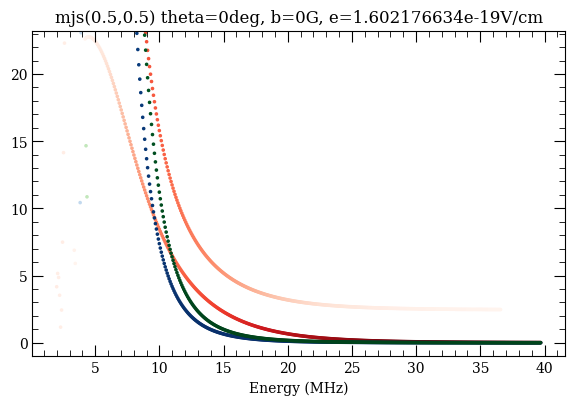

0        2.000000
1        2.000000
2        2.000000
3        2.076152
4        2.076152
          ...    
1923    39.847695
1924    39.923848
1925    39.923848
1926    39.923848
1927    40.000000
Name: r, Length: 1928, dtype: float64


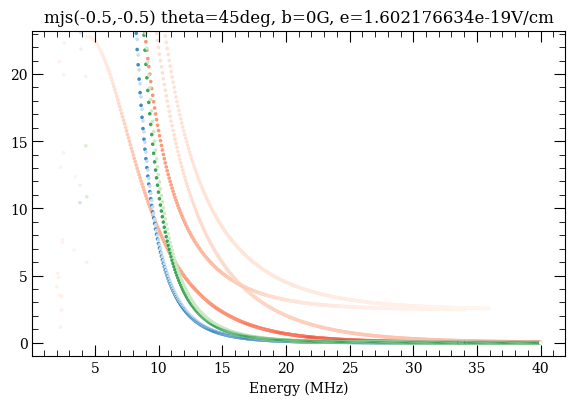

0        2.000000
1        2.000000
2        2.000000
3        2.076152
4        2.076152
          ...    
1923    39.847695
1924    39.923848
1925    39.923848
1926    39.923848
1927    40.000000
Name: r, Length: 1928, dtype: float64


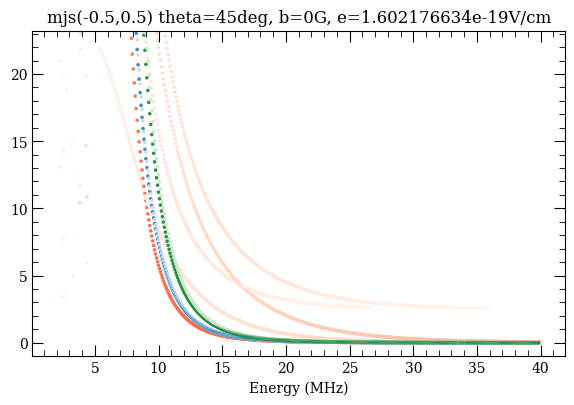

0        2.000000
1        2.000000
2        2.076152
3        2.076152
4        2.152305
          ...    
1341    39.695391
1342    39.771543
1343    39.771543
1344    39.847695
1345    39.847695
Name: r, Length: 1346, dtype: float64


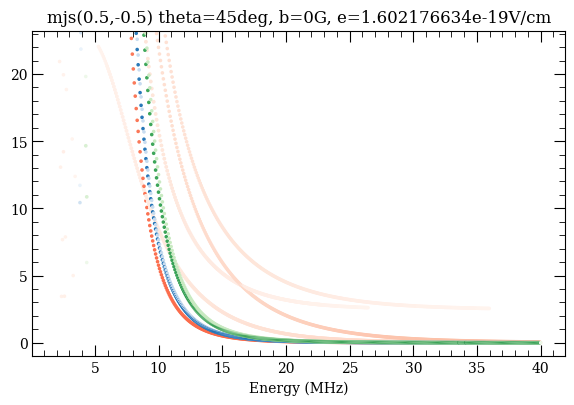

0        2.000000
1        2.000000
2        2.076152
3        2.076152
4        2.152305
          ...    
1341    39.695391
1342    39.771543
1343    39.771543
1344    39.847695
1345    39.847695
Name: r, Length: 1346, dtype: float64


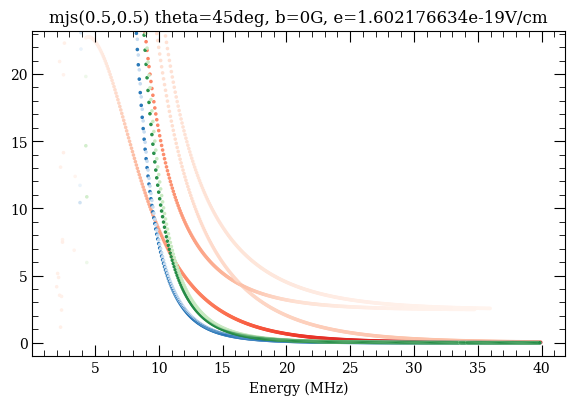

0        2.000000
1        2.000000
2        2.076152
3        2.076152
4        2.152305
          ...    
1347    39.695391
1348    39.771543
1349    39.771543
1350    39.847695
1351    39.847695
Name: r, Length: 1352, dtype: float64


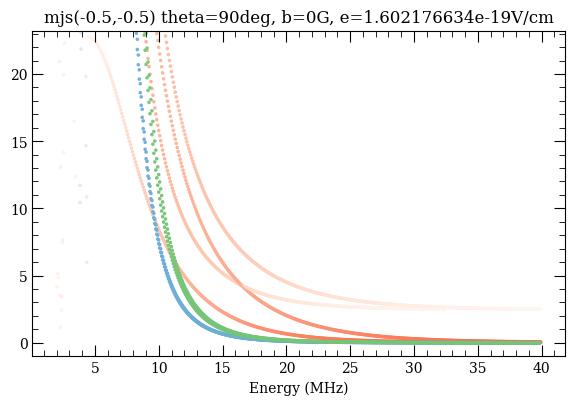

0        2.000000
1        2.000000
2        2.076152
3        2.076152
4        2.152305
          ...    
1347    39.695391
1348    39.771543
1349    39.771543
1350    39.847695
1351    39.847695
Name: r, Length: 1352, dtype: float64


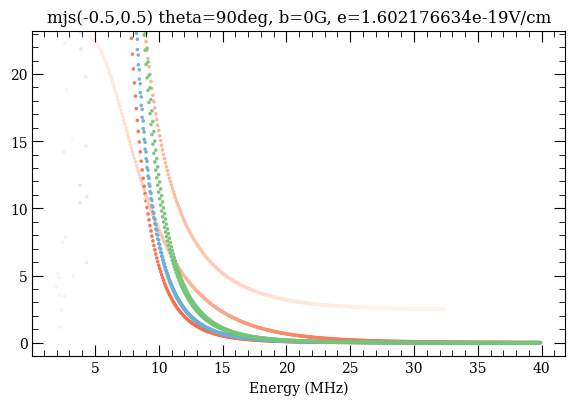

0        2.000000
1        2.000000
2        2.076152
3        2.076152
4        2.152305
          ...    
1347    39.695391
1348    39.771543
1349    39.771543
1350    39.847695
1351    39.847695
Name: r, Length: 1352, dtype: float64


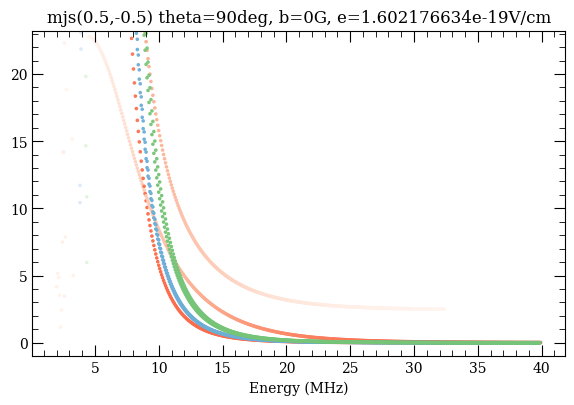

0        2.000000
1        2.000000
2        2.076152
3        2.076152
4        2.152305
          ...    
1347    39.695391
1348    39.771543
1349    39.771543
1350    39.847695
1351    39.847695
Name: r, Length: 1352, dtype: float64


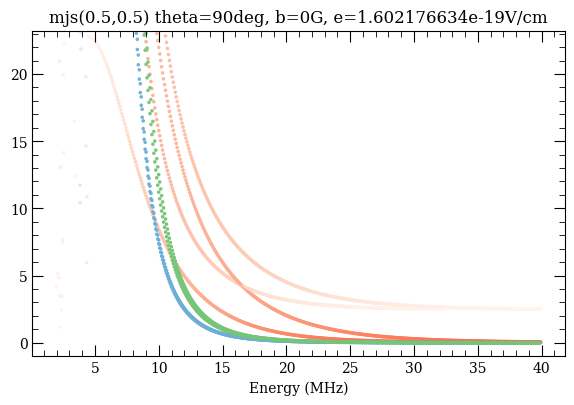

In [ ]:
import os
datapath_field = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\field-corrected\\'
if not os.path.exists(datapath_field + 'inter'):
    os.makedirs(datapath_field + 'inter')
if not os.path.exists(datapath_field + 'intra Rb'):
    os.makedirs(datapath_field + 'intra Rb')
if not os.path.exists(datapath_field + 'intra Cs'):
    os.makedirs(datapath_field + 'intra Cs')
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\angular\\inter intra\\polar\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)
# ax.set_ylim(-0.01, 0.01)

prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']
thetas = [0, 45, 90]
# system_atom = system_atom_dict[efield]
b=0
for theta in thetas:
    for mj1 in mj1_0s:
        for mj2 in mj2_0s:
            # print(overlapped_inter)
            overlapped_inter = pd.read_csv(datapath + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {b}G.csv')
            overlapped_intra_Rb = pd.read_csv(datapath + f'intra Rb\\mjs ({mj1}, {mj1}), theta {theta}, b {b}G.csv')
            overlapped_intra_Cs = pd.read_csv(datapath + f'intra Cs\\mjs ({mj2}, {mj2}), theta {theta}, b {b}G.csv')

            # print(overlapped_inter_big['energy'])
            fig, ax = plt.subplots(ncols=1, figsize=(6, 4))

            
            ax.set_ylabel(f"Energy ({energy_unit})")
            plt.tight_layout()
            plt.title(fr'mjs({mj1},{mj2}) theta={theta}deg, b={np.round(b,2)}G, e={e}V/cm')
            energy_lim = abs(defect*10)
            offset=defect/2
            min_energy = -energy_lim+offset
            max_energy = energy_lim+offset
            plt.ylim(-1, max_energy)
            energies = {'energy' : [], 'r' : [], 'overlap' : []}
            energy = [e - overlapped_inter['energy'].iloc[-1] for e in overlapped_inter['energy'][:-5]]
            energies['energy'] = energy
            energies['r'] = overlapped_inter['r'][:-5]
            energies['overlap'] = overlapped_inter['overlap'][:-5]
            scat = plt.scatter(
                energies['r'],
                abs(np.array(energies['energy'])),
                c=energies['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Reds'
            )
            print(overlapped_intra_Rb['r'][:-5])
            energies_Rb = {'energy' : [], 'r' : [], 'overlap' : []}
            energy_Rb = [e - overlapped_intra_Rb['energy'].iloc[-1] for e in overlapped_intra_Rb['energy'][:-5]]
            energies_Rb['energy'] = energy_Rb
            energies_Rb['r'] = overlapped_intra_Rb['r'][:-5]
            energies_Rb['overlap'] = overlapped_intra_Rb['overlap'][:-5]

            scat = plt.scatter(
                energies_Rb['r'],
                abs(np.array(energies_Rb['energy'])),
                c=energies_Rb['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Blues'
            )

            energies_Cs = {'energy' : [], 'r' : [], 'overlap' : []}
            energy_Cs = [e - overlapped_intra_Cs['energy'].iloc[-1] for e in overlapped_intra_Cs['energy'][:-5]]
            energies_Cs['energy'] = energy_Cs
            energies_Cs['r'] = overlapped_intra_Cs['r'][:-5]
            energies_Cs['overlap'] = overlapped_intra_Cs['overlap'][:-5]
                    

            scat = plt.scatter(
                energies_Cs['r'],
                abs(np.array(energies_Cs['energy'])),
                c=energies_Cs['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Greens'
            )
            plt.show()
            # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
            pd.DataFrame(energies).to_csv(datapath_field + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {b}G.csv')
            pd.DataFrame(energies_Rb).to_csv(datapath_field + f'intra Rb\\mjs ({mj1}, {mj1}), theta {theta}, b {b}G.csv')
            pd.DataFrame(energies_Cs).to_csv(datapath_field + f'intra Cs\\mjs ({mj2}, {mj2}), theta {theta}, b {b}G.csv')
            fig.savefig(figpath + f'theta {theta}deg b{np.round(b,3)}G e{e}Vcm mjs{ket1.m},{ket2.m}.png')
            plt.close()

C:\Users\tommy\AppData\Local\Temp\ipykernel_23112\724269080.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)


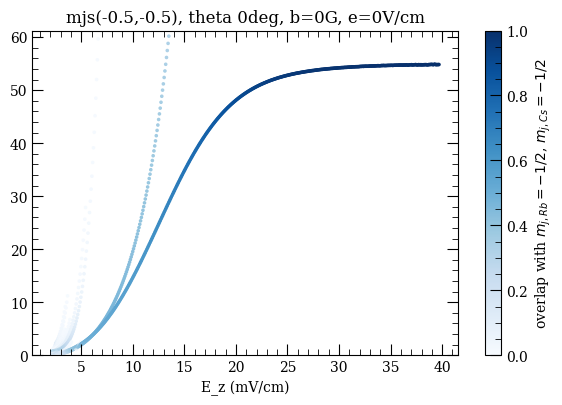

C:\Users\tommy\AppData\Local\Temp\ipykernel_23112\724269080.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


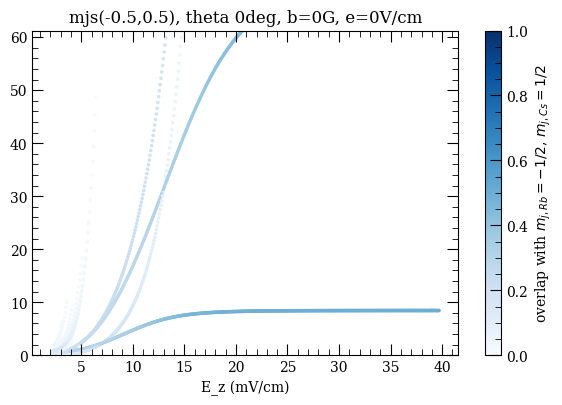

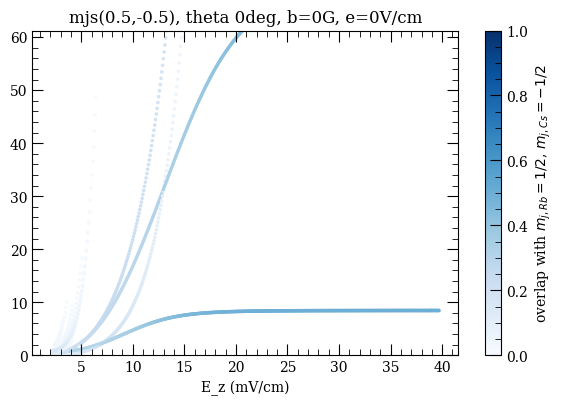

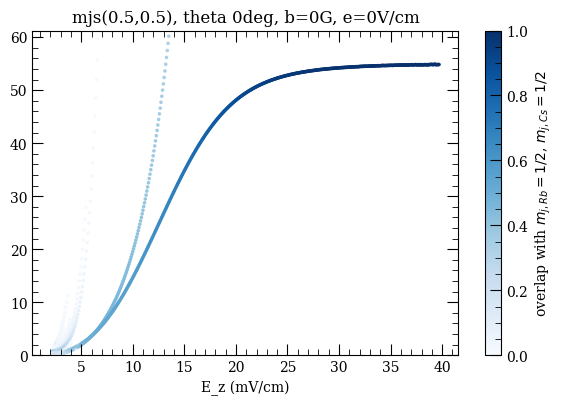

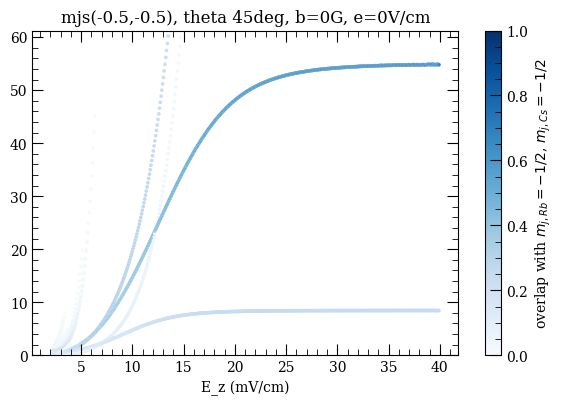

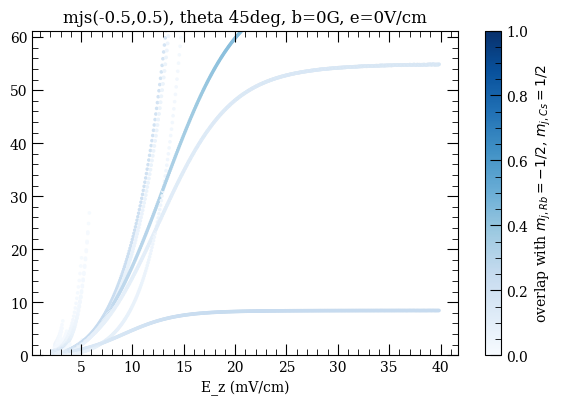

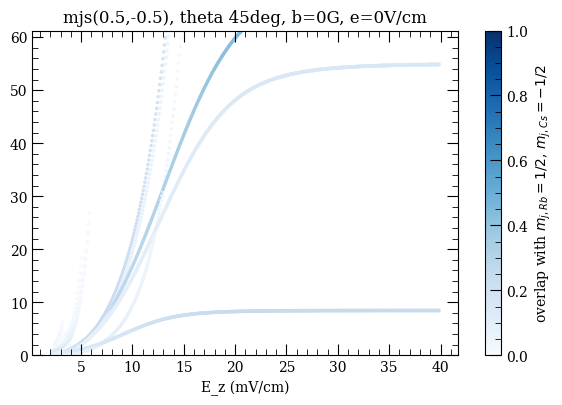

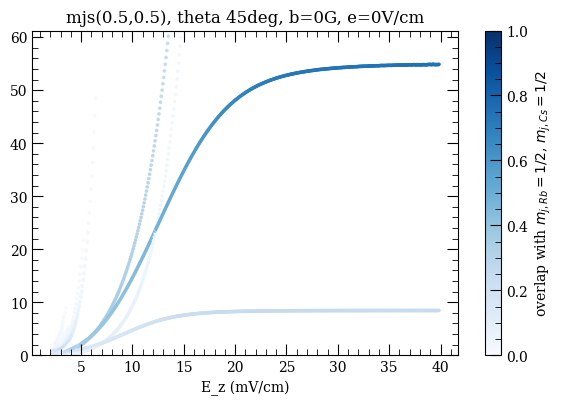

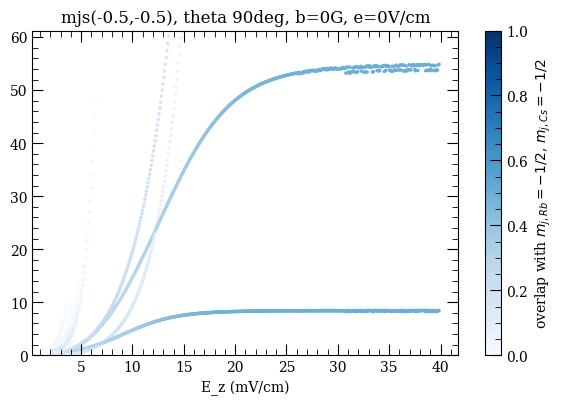

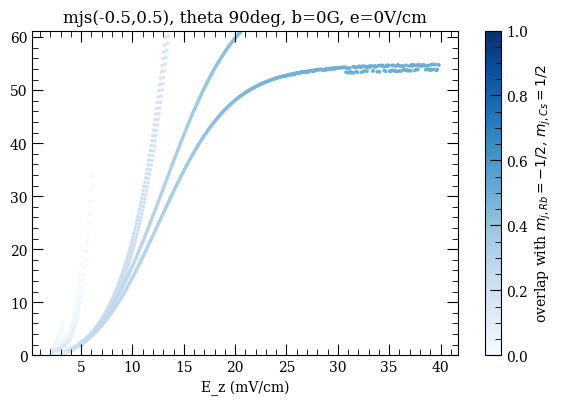

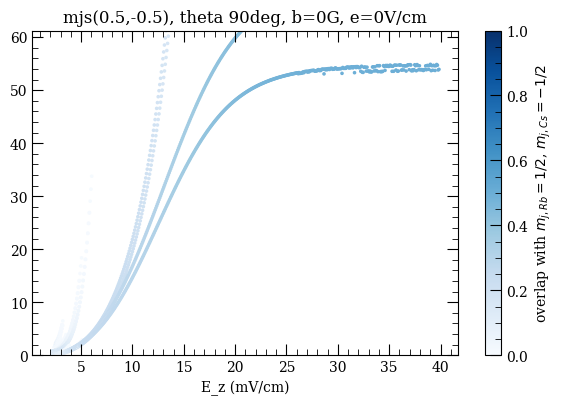

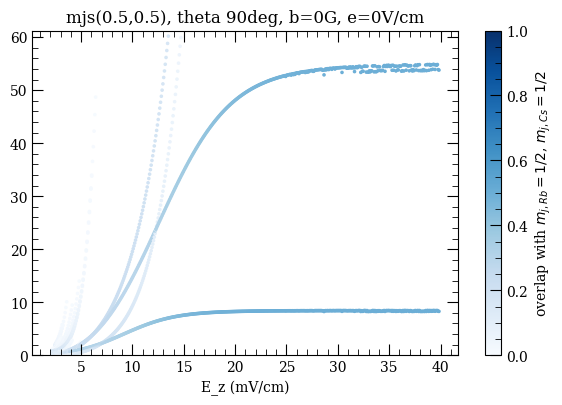

In [ ]:
# assymetry parameter
import os
datapath_assym = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\asymmetry\\'
if not os.path.exists(datapath_assym + 'inter'):
    os.makedirs(datapath_assym + 'inter')
if not os.path.exists(datapath_assym + 'intra Rb'):
    os.makedirs(datapath_assym + 'intra Rb')
if not os.path.exists(datapath_assym + 'intra Cs'):
    os.makedirs(datapath + 'intra Cs')
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\assymetry\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)
# ax.set_ylim(-0.01, 0.01)

prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']

# system_atom = system_atom_dict[efield]

thetas = [0, 45, 90]
b=0
for theta in thetas:
    for mj1 in mj1_0s:
        for mj2 in mj2_0s:
            # print(overlapped_inter)
            corrected_inter = pd.read_csv(datapath_field + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {b}G.csv')
            corrected_intra_Rb = pd.read_csv(datapath_field + f'intra Rb\\mjs ({mj1}, {mj1}), theta {theta}, b {b}G.csv')
            corrected_intra_Cs = pd.read_csv(datapath_field + f'intra Cs\\mjs ({mj2}, {mj2}), theta {theta}, b {b}G.csv')
            # print(corrected_inter)
            # print(overlapped_inter_big['energy'])
            fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
          
            ax.set_xlabel("E_z (mV/cm)")
            plt.tight_layout()
            plt.title(fr'mjs({mj1},{mj2}), theta {theta}deg, b={np.round(b,2)}G, e={e}V/cm')
            energy_lim = abs(60)
            offset=defect/2
            min_energy = -energy_lim+offset
            max_energy = energy_lim+offset
            plt.ylim(0, max_energy)
            energies = {'energy' : [], 'r' : [], 'overlap' : []}

            big_lookup = dict(zip(corrected_intra_Rb['r'], corrected_intra_Rb['energy']))
            third_lookup = dict(zip(corrected_intra_Cs['r'], corrected_intra_Cs['energy']))

            # 2. Initialize your results (will be same length as the loop source)
            asym = {
            'energy': [],
            'r': [],
            'overlap': []
            }

            # 3. Iterate through EVERY element of the PRIMARY dataset
            for i, r in enumerate(corrected_inter['r']):
                current_energy = corrected_inter['energy'][i]
                # print(i)
                # Use .get(theta, 0) to "safely" grab the value. 
                # If the theta doesn't exist in that specific set, it defaults to 0.
                val_big = big_lookup.get(r, 0)
                val_third = third_lookup.get(r, 0)

                # 4. Perform your manipulation (e.g., subtracting both from the original)
                final_calc = current_energy/np.sqrt(val_big * val_third)

                # 5. Append to keep the output arrays aligned with the input
                asym['energy'].append(final_calc)
                asym['r'].append(r)
                asym['overlap'].append(corrected_inter['overlap'][i])
                    
                    
                    

            # print(energies['energy']-overlapped_inter['energy'])

            scat = plt.scatter(
                asym['r'],
                abs(np.array(asym['energy'])),
                c=asym['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Blues'
            )

            asym.to_csv(datapath_assym + f'\\mjs ({mj1}, {mj2}), theta {theta}deg, b {b}G.csv')
            plt.colorbar(label = fr'overlap with $m_{{j,Rb}} = {int(2*mj1)}/2$, $m_{{j,Cs}} = {int(2*mj2)}/2$')
            plt.show()
            # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
            fig.savefig(figpath + f'sep {r}um b{np.round(b,3)}G e{e}Vcm mjs{ket1.m},{ket2.m}.png')
            plt.close()


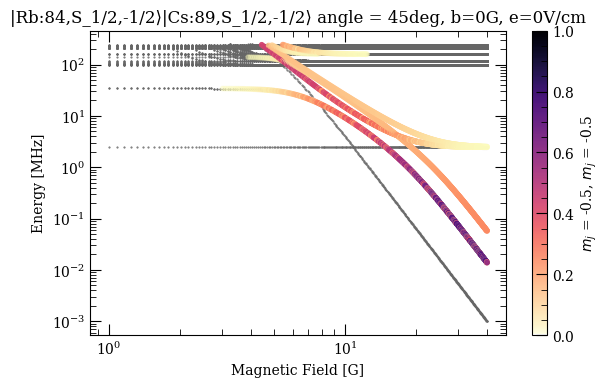

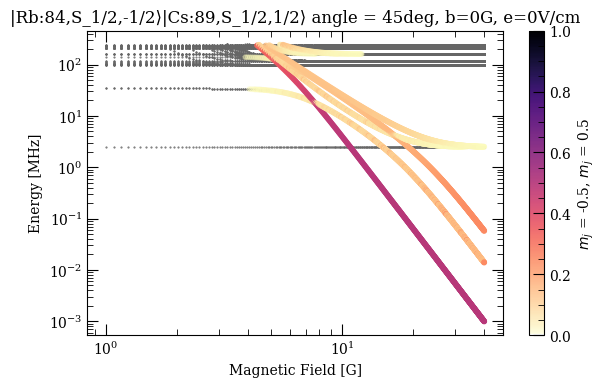

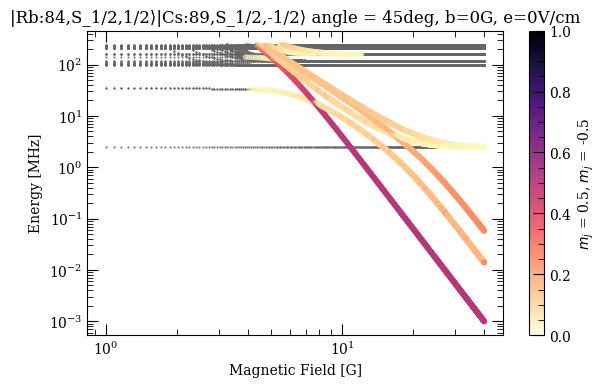

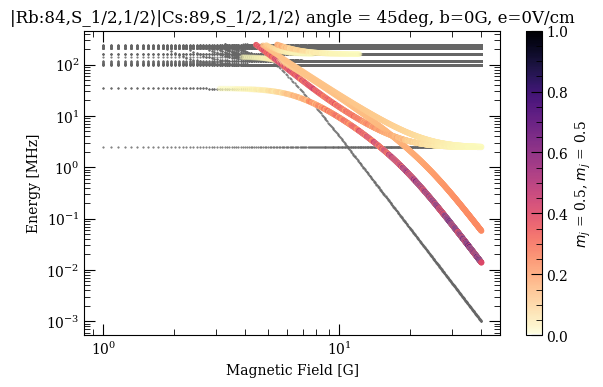

In [ ]:
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\separations\\overlapped\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]}\\to {orbs[l1_1]}{orbs[l2_1]}\\j1j2({j1_0},{j2_0})\\log\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)

for mj1 in mj1_0s:
    for mj2 in mj2_0s:

        ket1, ket2 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=mj1), pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=mj2)
        overlaps1 = [system.get_eigenbasis().get_overlaps([ket1, ket2]) for system in system_pairs]


        # plt.axhline(defect, color='r', linewidth=2, alpha=1, linestyle='dotted')
        fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_xlabel("E_z (mV/cm)")
        ax.set_ylabel(f"Energy ({energy_unit})")
        ax.set_title(fr'separations $\mu$m')
        plt.tight_layout()
        plt.title(fr'{str(ket1)}{str(ket2)} angle = {angle}deg, b={b}G, e={e}V/cm')
        energy_lim = abs(defect + defect*2)
        offset=defect/2
        min_energy = -energy_lim+offset
        max_energy = energy_lim+offset
        # plt.ylim(min_energy, max_energy)
        # plt.xlim(2, 2.7)
        plt.ylabel(f"Energy [{energy_unit}]")
        plt.xlabel("Magnetic Field [G]")
        # ax.plot(e_fields_sub, energies)

        for x, es in zip(rs, energies):
            plt.plot([x] * len(es), abs(es), c='.9', ls="None", marker=".", ms=1, zorder=-1)
        min_overlap = 0.000
        for x, es, os in zip(rs, energies, overlaps1):
            inds = np.argwhere(os > min_overlap).flatten()
            inds = inds[np.argsort(os[inds])]
            if len(inds) > 0:
                scat = plt.scatter(
                    [x] * len(es[inds]),
                    abs(es[inds]),
                    c=os[inds],
                    s=10,
                    vmin=0,
                    vmax=1,
                    cmap=alphamagma,
                )
        fig.colorbar(scat, ax=ax, label=fr"$m_j$ = {ket1.m}, $m_j$ = {ket2.m}")
        # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
        fig.savefig(figpath + f'level pairstate deg{angle} b{b}G e{e}Vcm mjs{ket1.m},{ket2.m}.png')


{'mjs0-0.5-0.5': [], 'mjs0-0.50.5': [], 'mjs00.5-0.5': [], 'mjs00.50.5': []}


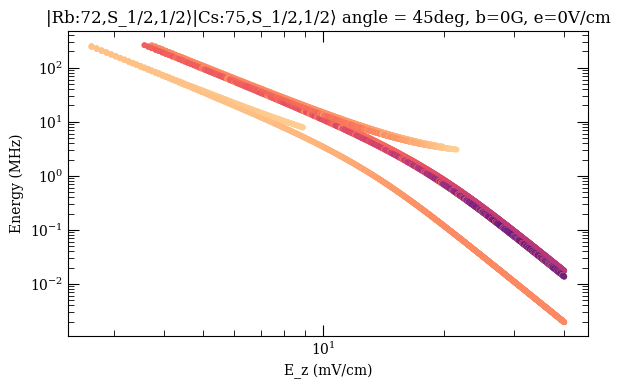

In [10]:
min_overlap = 0.1
energies_dict_0 = {f'mjs0{mj1_0}{mj2_0}': [] for mj1_0 in mj1_0s for mj2_0 in mj2_0s}
print(energies_dict_0)
fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel("E_z (mV/cm)")
ax.set_ylabel(f"Energy ({energy_unit})")
ax.set_title(fr'separations $\mu$m')
plt.tight_layout()
plt.title(fr'{str(ket1)}{str(ket2)} angle = {angle}deg, b={b}G, e={e}V/cm')

for mj1_0 in mj1_0s:
    for mj2_0 in mj2_0s:
        ket1_0 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=mj1_0)
        ket2_0 = pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=mj2_0)
        overlaps1 = [system.get_eigenbasis().get_overlaps([ket1_0, ket2_0]) for system in system_pairs]

        energies1=[]
        ds=[]
        for x, es, os in zip(rs, energies, overlaps1):
            inds = np.argwhere(os > min_overlap).flatten()
            inds = inds[np.argsort(os[inds])]
            if len(inds) > 0:
                scat = plt.scatter(
                    [x] * len(es[inds]),
                    abs(es[inds]),
                    c=os[inds],
                    s=10,
                    vmin=0,
                    vmax=1,
                    cmap=alphamagma,
                )
                energies1 = np.append(energies1, es[inds])
                ds = np.append(ds, [x] * len(es[inds]))
        energies_dict_0[f'rs{mj1_0}{mj2_0}'] = ds
        energies_dict_0[f'mjs0{mj1_0}{mj2_0}'] = energies1

[ 2.64128257  2.64128257  2.71943888 ... 39.92184369 40.
 40.        ]
182 182
[[445056.6512226]]
[117.84927326]


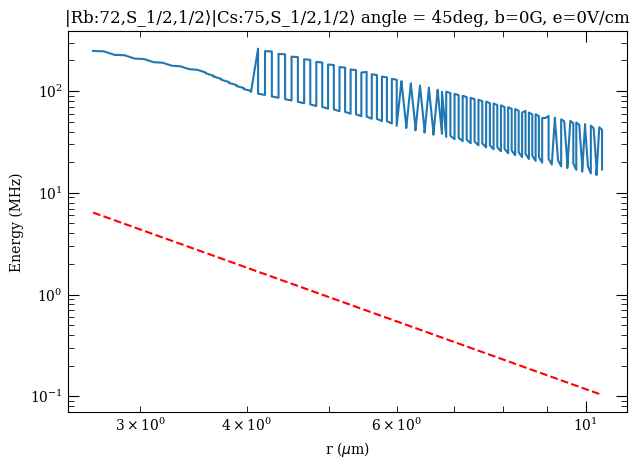

In [18]:
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\log fitted\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)

datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\log fitted\\'
if not os.path.exists(datapath):
    os.makedirs(datapath)

def func(r, c):
    return c/(r)**3 
rmax=10.5
mj1_0, mj2_0 = -1/2, -1/2
ds = energies_dict_0[f'rs{mj1_0}{mj2_0}']
print(ds)
ds = ds[np.argwhere(ds<rmax)].flatten()[::2]

energy = energies_dict_0[f'mjs0{mj1_0}{mj2_0}']
energy = energy[np.argwhere(ds<rmax)].flatten()
print(len(ds), len(energy))
popt, pcov = scipy.optimize.curve_fit(func, ds, energy)
fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r"r ($\mu$m)")
ax.set_ylabel(f"Energy ({energy_unit})")
ax.set_title(fr'separations $\mu$m')
plt.tight_layout()
plt.title(fr'{str(ket1)}{str(ket2)} angle = {angle}deg, b={b}G, e={e}V/cm')

ax.plot(ds, abs(energy))
ax.plot(ds, abs(func(ds, *popt)), linestyle='dashed', color='red')
fig.savefig(figpath + f'deg{angle} b{b}G e{e}Vcm mjs{mj1_0},{mj2_0}.png')
print(pcov)
C3 = pd.DataFrame({'c3' : [popt[0]], 'error' : [np.sqrt(np.diag(pcov))[0]]})
C3.to_csv(datapath + f'deg{angle} b{b}G e{e}Vcm mjs{mj1_0},{mj2_0}.csv', index=False)

print(popt)